<a href="https://colab.research.google.com/github/nmfairuz/ML-Coding/blob/main/Sleep_Health_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Dataset:


[Sleep Health & Daily Performance Dataset](https://www.kaggle.com/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset)


This dataset contains 100,000 synthetic patient records designed for comprehensive sleep health analysis, disorder risk prediction, and cognitive performance modeling. Every record captures a complete daily snapshot: sleep architecture measurements, lifestyle behaviors, psychological state, and next-day cognitive outcomes.




## Load Dataset:


In [2]:
import pandas as pd
df=pd.read_csv("sleep_health_dataset.csv")

In [3]:
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [7]:
df.columns

Index(['person_id', 'age', 'gender', 'occupation', 'bmi', 'country',
       'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage',
       'deep_sleep_percentage', 'sleep_latency_mins',
       'wake_episodes_per_night', 'caffeine_mg_before_bed',
       'alcohol_units_before_bed', 'screen_time_before_bed_mins',
       'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score',
       'work_hours_that_day', 'chronotype', 'mental_health_condition',
       'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work',
       'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season',
       'day_type', 'cognitive_performance_score', 'sleep_disorder_risk',
       'felt_rested'],
      dtype='object')

The non-numerical datasets will require encoding laters.

cognitive_performance_score	sleep_disorder_risk	felt_rested -> These 3 cols shouldnt be used for predicting felt_rested or not.

Also, skip the id col, it's just identifier for each person.

In [8]:
df.shape

(100000, 32)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

- 13 integer columns
- 11 float columns
- 8 categorical (object) columns

Doesn't have any missing values : no need to fill NA.

In [10]:
df.describe()

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,...,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,...,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,...,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,...,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,...,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


In [11]:
df["felt_rested"].value_counts()

,count
felt_rested,
0,60988
1,39012


In [12]:
df["felt_rested"].value_counts(normalize=True)

,proportion
felt_rested,
0,0.60988
1,0.39012


How many unique occupation:

In [13]:
df['occupation'].value_counts()

,count
occupation,
Student,14851
Software Engineer,12068
Nurse,10073
Manager,8101
Teacher,8047
Doctor,7868
Retired,7036
Sales,7017
Freelancer,7016


gender distribution:

In [14]:
df['gender'].value_counts()

,count
gender,
Female,50203
Male,47823
Other,1974


Country Distribution

In [15]:
df["country"].value_counts()

,count
country,
USA,20050
India,17840
Japan,8089
UK,8024
Brazil,7146
Germany,6026
Canada,4995
France,4982
Australia,4948


# EDA

## How are the numerical features distributed?

use histogram

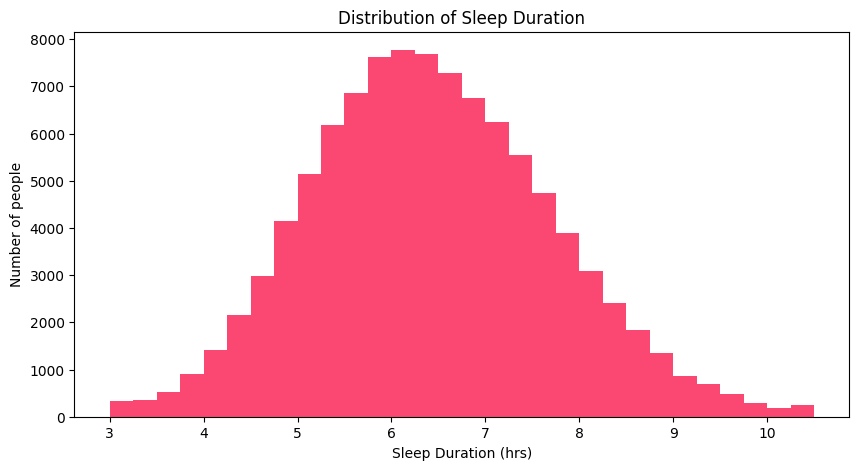

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(df['sleep_duration_hrs'],bins=30, color='#fa4872')
plt.title("Distribution of Sleep Duration")
plt.xlabel("Sleep Duration (hrs)")
plt.ylabel("Number of people")
plt.show()

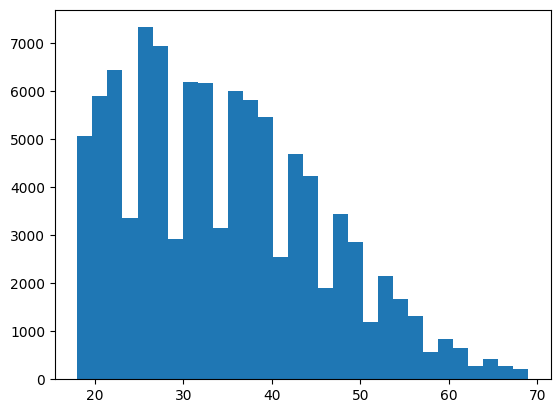

In [30]:
plt.hist(df["age"], bins=30)
plt.show()

Most of the people are from 20-45

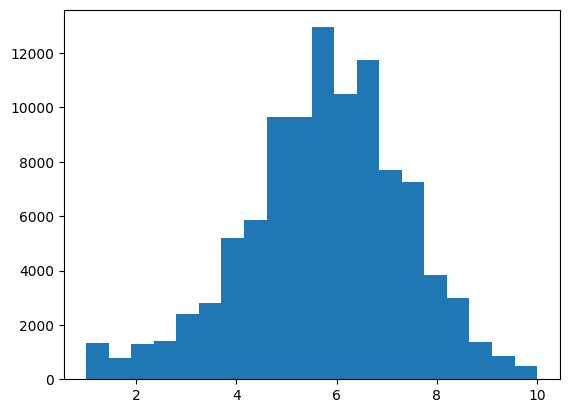

In [31]:
plt.hist(df["stress_score"], bins=20)
plt.show()

Most of the people has stress score of 5-7.

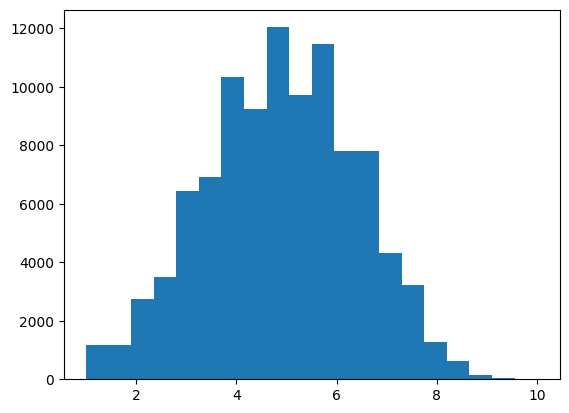

In [32]:
plt.hist(df["sleep_quality_score"], bins=20)
plt.show()

Most of the people has sleep score of 4-6.

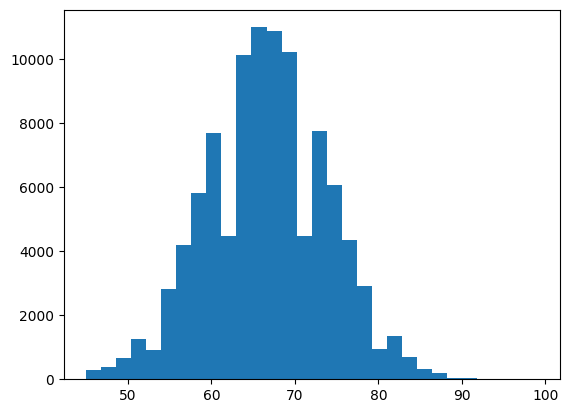

In [33]:
plt.hist(df["heart_rate_resting_bpm"], bins=30)
plt.show()

Most of the people has heart rate 65-72

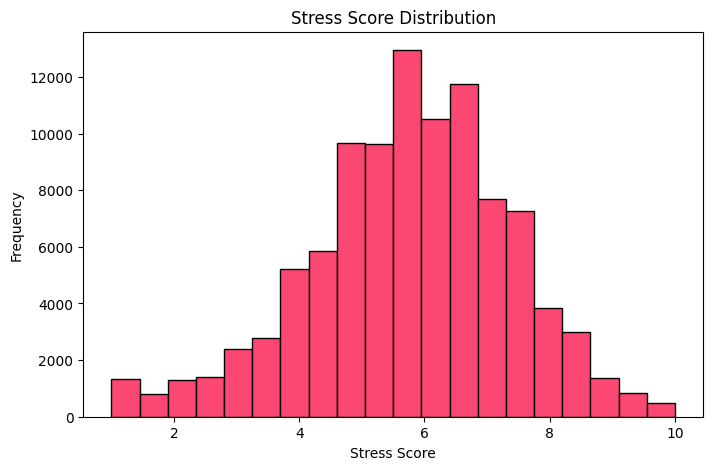

In [35]:
plt.figure(figsize=(8,5))

plt.hist(
    df["stress_score"],
    bins=20,
    color="#fa4872",
    edgecolor="black"
)

plt.title("Stress Score Distribution")
plt.xlabel("Stress Score")
plt.ylabel("Frequency")

plt.show()

Do people who feel rested actually sleep longer?

In [37]:
df.groupby("felt_rested")["sleep_duration_hrs"].mean()

,sleep_duration_hrs
felt_rested,
0,5.972262
1,7.130174


> Participants who reported feeling rested slept approximately 1.16 hours longer on average than those who did not, suggesting sleep duration is likely to be an important predictor.

Instead of manually checking 20+ features, you let Python summarize them all. This is a good habit whenever you have many columns.

In [40]:
numerical_cols=df.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_cols:
    if col != 'felt_rested':
        print(f"\n {col} :\n")
        print(df.groupby('felt_rested')[col].mean())


 person_id :

felt_rested
0    50007.440578
1    49989.649698
Name: person_id, dtype: float64

 age :

felt_rested
0    34.875385
1    34.443428
Name: age, dtype: float64

 bmi :

felt_rested
0    26.460240
1    26.023024
Name: bmi, dtype: float64

 sleep_duration_hrs :

felt_rested
0    5.972262
1    7.130174
Name: sleep_duration_hrs, dtype: float64

 sleep_quality_score :

felt_rested
0    4.294189
1    5.773106
Name: sleep_quality_score, dtype: float64

 rem_percentage :

felt_rested
0    19.918607
1    20.752609
Name: rem_percentage, dtype: float64

 deep_sleep_percentage :

felt_rested
0    20.077177
1    20.528827
Name: deep_sleep_percentage, dtype: float64

 sleep_latency_mins :

felt_rested
0    20.609841
1    18.628319
Name: sleep_latency_mins, dtype: float64

 wake_episodes_per_night :

felt_rested
0    3.693973
1    2.803573
Name: wake_episodes_per_night, dtype: float64

 caffeine_mg_before_bed :

felt_rested
0    40.264478
1    36.637445
Name: caffeine_mg_before_bed, dtype

person_id : Doesn't matter.

We'll drop it.

age Difference:

34.88 vs 34.44

Only about 0.43 years.

Probably a weak predictor by itself.

sleep_duration_hrs : 5.97 vs 7.13

Difference: ≈ 1.16 hours

This is a strong signal.

sleep_quality_score : 4.29 vs 5.77

Difference: ≈ 1.48

Also a strong predictor.

stress_score 6.20 vs 4.99

Difference: ≈ 1.21

Another strong feature.

work_hours_that_day 7.83 vs
6.04

Difference:
≈ 1.8 hours

It suggests working longer is associated with feeling less rested.

wake_episodes_per_night

Exactly.

3.69 vs
2.80

That's almost one fewer wake-up.

 if u wake up 1 less time then u have better sleep

That seems meaningful.

shift_work : 11% vs 4%

This one is actually stronger than it looks.

Shift workers appear much less likely to feel rested.

Report format:
* Sleep duration shows one of the largest differences between rested and non-rested individuals.
* Sleep quality is substantially higher among rested individuals.
* Higher stress scores are associated with lower likelihood of feeling rested.
* Shift workers appear less likely to report feeling rested.
* Age and resting heart rate show relatively small differences.

## Correlation Heatmap

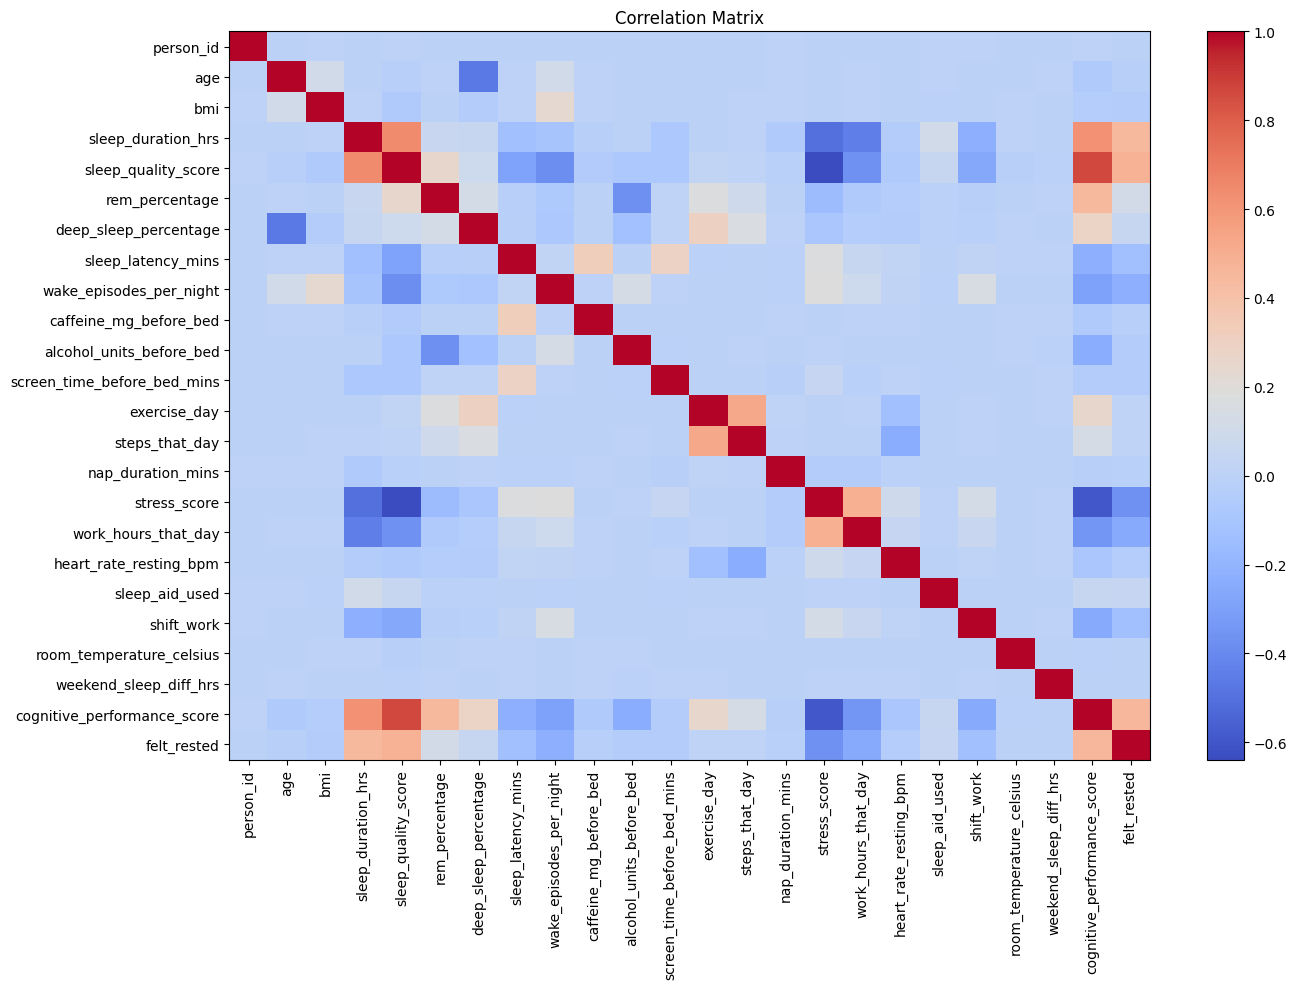

In [41]:
import matplotlib.pyplot as plt
corr=df.select_dtypes(include=["int64", "float64"]).corr() # Correlation calculations only work on numbers.
# .corr(): This computes the Pearson correlation coefficient matrix. Every numerical column is compared to every other numerical column, generating a score between -1 (perfect negative relationship) and +1 (perfect positive relationship).
plt.figure(figsize=(14, 10))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)



plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

**.corr():** This computes the Pearson correlation coefficient matrix. Every numerical column is compared to every other numerical column, generating a score between -1 (perfect negative relationship) and +1 (perfect positive relationship).

**plt.xticks(...) and plt.yticks(...):** Without these, your plot would just show numbers (0, 1, 2...) on the axes. This replaces those numbers with your actual column names.

 rotation=90: This flips the X-axis text sideways so the 32 column names don't crash into each other.

This shows which numerical features tend to move together.

The Color Rule for cmap="coolwarm":

🔴 **Dark Red / Orange** (**Positive** Correlation): Both variables move in the same direction. If one goes up, the other goes up. (Example: Higher sleep duration = higher cognitive score).

🔵 **Dark Blue / Purple** (**Negative** Correlation): Variables move in opposite directions. If one goes up, the other drops. (Example: Higher stress = lower sleep quality).

⚪ **Light/Faint/White** (**No** Correlation): The variables have zero relationship. They ignore each other. (Example: Room temperature has nothing to do with your ID number).

In [42]:
# 1. Calculate the correlation matrix
corr_matrix = df.select_dtypes(include=["int64", "float64"]).corr()

# 2. Grab only the 'felt_rested' column and sort it from highest to lowest
felt_rested_corr = corr_matrix[['felt_rested']].sort_values(by='felt_rested', ascending=False)

print(felt_rested_corr)

                             felt_rested
felt_rested                     1.000000
sleep_quality_score             0.478843
cognitive_performance_score     0.451526
sleep_duration_hrs              0.443114
rem_percentage                  0.119252
deep_sleep_percentage           0.051823
sleep_aid_used                  0.042328
exercise_day                    0.009143
steps_that_day                  0.008043
person_id                      -0.000301
room_temperature_celsius       -0.001677
weekend_sleep_diff_hrs         -0.002923
nap_duration_mins              -0.015957
age                            -0.019091
caffeine_mg_before_bed         -0.025494
heart_rate_resting_bpm         -0.041099
alcohol_units_before_bed       -0.044429
screen_time_before_bed_mins    -0.045657
bmi                            -0.047608
sleep_latency_mins             -0.127440
shift_work                     -0.129592
wake_episodes_per_night        -0.226104
work_hours_that_day            -0.251302
stress_score    

| Correlation | Interpretation     |
| ----------- | ------------------ |
| 0.00–0.20   | Very weak          |
| 0.20–0.40   | Weak to moderate   |
| 0.40–0.60   | Moderate to strong |
| 0.60–0.80   | Strong             |
| 0.80–1.00   | Very strong        |

Remember, these are rules of thumb, not strict cutoffs.

### Summary:

Strongest relationships:
* Sleep quality score
- Sleep duration
- Stress score
- Moderate relationships
- Work hours
- Wake episodes

Weak relationships
* REM percentage
* Sleep latency
* Shift work

Little or no linear relationship
* Age
* Room temperature
* Weekend sleep difference
* Person ID

That's a solid EDA summary.

## Building the ML pipeline:

### Drop unwanted cols

In [44]:
df=df.drop(
    columns=[
        "person_id",
        "cognitive_performance_score",
        "sleep_disorder_risk"
    ]
)


### Separate X and Y

In [45]:
X=df.drop(columns=["felt_rested"])
y=df["felt_rested"]

### Find categorical columns

In [46]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
print(categorical_cols)

['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'day_type']


### Find numerical columns

In [47]:
numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print(numerical_cols)

['age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs']


```
X
│
├── Numerical columns
│
└── Categorical columns
```

They need different preprocessing.

Numerical :
StandardScaler()

while

Categorical :
OneHotEncoder()

How do we tell Python this?

With a ColumnTransformer.

## ColumnTransformer

ColumnTransformer : says

Numbers -> Scale them

Strings -> One-hot encode them

In [48]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
preprocessor=ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

"num" : Just a name.

Could be "banana" and it'd still work.

It's just a label.

**StandardScaler()** :
Apply this
ONLY
to
**numerical_cols**

"cat" : Another label.

**OneHotEncoder(...) :** Apply ONLY to **categorical_cols**


**handle_unknown="ignore" :** This is SUPER important.

Suppose training data has
Japan,
Korea,
USA

Tomorrow someone from
Ireland
appears.

Without this option...
💥 Error.

With it...
Everything keeps working.

This is why it's a standard setting in many projects.

## PipeLine

Raw Data → Preprocessing → Random Forest → Prediction

That's a pipeline.


Instead of manually doing it, we put everything together.

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [50]:
pipeline=Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression())
    ]
)


**ColumnTransformer** is the "What to do to each column" map. It ensures numbers get scaled and text gets encoded automatically without you separating them manually.

**Pipeline** is the "Assembly Line". It glues the data-cleaning map straight to the machine learning model. It lets you go from Raw Data $\rightarrow$ Prediction in a single line of code (pipeline.predict()), keeping your code clean, safe from bugs, and ready for production.

## Train / Test Split


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

target distribution :
61% vs 39%

Without stratify, the split might accidentally become:

Train : 70/30

Test : 50/50

That's not representative.

> stratify=y keeps approximately the same class proportions in both sets.

## Train Model / Pipeline Fit

In [54]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi',
                                                   'sleep_duration_hrs',
                                                   'sleep_quality_score',
                                                   'rem_percentage',
                                                   'deep_sleep_percentage',
                                                   'sleep_latency_mins',
                                                   'wake_episodes_per_night',
                                                   'caffeine_mg_before_bed',
                                                   'alcohol_units_before_bed',
                                                   'screen_time_before_bed_mins',
                                                   'exercise_day',
                                                   'steps_that_day',
                                                   'nap_duration_mins',
                                                   'stress_score',
                                                   'work_hours_that_day',
                                                   'heart_rate_resting_bpm',
                                                   'sleep_aid_used',
                                                   'shift_work',
                                                   'room_temperature_celsius',
                                                   'weekend_sleep_diff_hrs']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'occupation',
                                                   'country', 'chronotype',
                                                   'mental_health_condition',
                                                   'season', 'day_type'])])),
                ('classifier', LogisticRegression())])

We don't hve to call StandardScaler.fit() or OneHotEncoder.fit()

The pipeline will do it for us!

We never manually transformed the test data.

The pipeline handled preprocessing automatically using the transformations learned from the training data.

This is one of the biggest reasons pipelines are recommended: they help prevent accidental mistakes like fitting preprocessing separately on the test set.

## Prediction

In [55]:
predictions = pipeline.predict(X_test)

In [60]:
y_pred = pipeline.predict(X_test)

```
Raw Data (X)
        │
        ▼
Train/Test Split
        │
        ▼
ColumnTransformer
    ├── Numerical → StandardScaler
    └── Categorical → OneHotEncoder
        │
        ▼
Logistic Regression
```

## Predict probabilities

In [57]:
y_prob=pipeline.predict_proba(X_test)
print(y_prob[:5])

[[0.40643723 0.59356277]
 [0.62836949 0.37163051]
 [0.13327395 0.86672605]
 [0.35718893 0.64281107]
 [0.34186797 0.65813203]]


40% chance 1st one is not rested, 60% chance that rested

## Evaluate the model:

In [58]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

#### Accuracy

In [61]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7363


#### Classification Report

In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.82      0.79     12198
           1       0.68      0.60      0.64      7802

    accuracy                           0.74     20000
   macro avg       0.72      0.71      0.72     20000
weighted avg       0.73      0.74      0.73     20000



#### Confusion Matrix

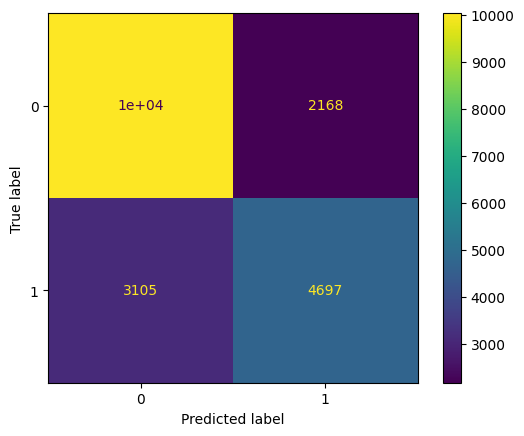

In [63]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

In [65]:
print(confusion_matrix(y_test, y_pred))

[[10030  2168]
 [ 3105  4697]]


```
                Predicted

             0           1

Actual 0   10030      2168

Actual 1    3105      4697
```

#### ROC-AUC

In [64]:
roc_auc = roc_auc_score(y_test, y_prob[:, 1])

print(f"ROC-AUC: {roc_auc:.4f}")
# The [:, 1] selects the probability of class 1 ("felt rested").

ROC-AUC: 0.8125


| ROC-AUC | Quality         |
| ------- | --------------- |
| 0.50    | Random guessing |
| 0.60    | Weak            |
| 0.70    | Acceptable      |
| 0.80    | Good            |
| 0.90+   | Excellent       |


**Strengths :**

- Clean preprocessing pipeline

- Proper train/test split

- No leakage

- Used OneHotEncoder correctly

- Used StandardScaler correctly

- Used ROC-AUC

- Used Classification Report

- Used Confusion Matrix

- Reproducible (random_state=42)

That already puts this above many beginner notebooks.

**Weaknesses :**

Logistic Regression assumes something close to linear relationships.

But the dataset description?

It literally said:

Sleep duration has an inverted-U relationship with cognitive performance.

Logistic Regression cannot naturally model that kind of non-linear pattern.

Tree-based models often can.

## Can another model perform better without changing the preprocessing workflow?

One of the biggest advantages of using a Pipeline is that swapping models is easy.

For example, replacing Logistic Regression with a Random Forest only requires changing the model step:

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline # Make sure Pipeline is imported too!

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42
         ))
    ]
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline # Make sure Pipeline is imported too!

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42  # Added the underscore here!
         ))
    ]
)

Everything else—data loading, preprocessing, train/test split, evaluation—stays the same.

### Train 2nd Model

In [68]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi',
                                                   'sleep_duration_hrs',
                                                   'sleep_quality_score',
                                                   'rem_percentage',
                                                   'deep_sleep_percentage',
                                                   'sleep_latency_mins',
                                                   'wake_episodes_per_night',
                                                   'caffeine_mg_before_bed',
                                                   'alcohol_units_before_bed',
                                                   'screen_time_before_bed_mins',
                                                   'exercise_day',
                                                   'steps_that_day',
                                                   'nap...
                                                   'stress_score',
                                                   'work_hours_that_day',
                                                   'heart_rate_resting_bpm',
                                                   'sleep_aid_used',
                                                   'shift_work',
                                                   'room_temperature_celsius',
                                                   'weekend_sleep_diff_hrs']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'occupation',
                                                   'country', 'chronotype',
                                                   'mental_health_condition',
                                                   'season', 'day_type'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

### Predict with 2nd Model

In [69]:
y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)

We never manually scaled anything.

We never encoded anything.

The pipeline handles all of that.

### Evaluate 2nd Model

In [70]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(f"ROC-AUC: {roc_auc_score(y_test, y_prob[:,1]):.4f}")

Accuracy: 0.7372
              precision    recall  f1-score   support

           0       0.77      0.81      0.79     12198
           1       0.68      0.62      0.65      7802

    accuracy                           0.74     20000
   macro avg       0.72      0.72      0.72     20000
weighted avg       0.73      0.74      0.74     20000

[[9883 2315]
 [2940 4862]]
ROC-AUC: 0.8200


| Model               | Accuracy | Precision | Recall | F1 | ROC-AUC |
| ------------------- | -------: | --------: | -----: | -: | ------: |
| Logistic Regression |        ? |         ? |      ? |  ? |       ? |
| Random Forest       |        ? |         ? |      ? |  ? |       ? |


| Model               |   Accuracy |  Precision |     Recall |         F1 |    ROC-AUC |
| ------------------- | ---------: | ---------: | ---------: | ---------: | ---------: |
| Logistic Regression | **73.63%** | **68.00%** | **60.00%** | **64.00%** | **81.25%** |
| Random Forest       | **73.72%** | **68.00%** | **62.00%** | **65.00%** | **82.00%** |


The Random Forest improved almost every metric, but only by a small amount.

1. We used default hyperparameters
```
RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
```
That's a reasonable baseline, but probably not the best model for this dataset.

2. The dataset is relatively "clean"

It's synthetic and has:

- no missing values,
- sensible feature ranges,
- and clear relationships.

Sometimes a simple model like Logistic Regression already performs surprisingly well on such data.

3. We haven't tuned anything

Real-world Random Forests are often tuned using parameters like:

- max_depth
- min_samples_split
- min_samples_leaf
- max_features

Those can make a meaningful difference.

### Conclusion
Random Forest achieved slightly higher Accuracy, Recall, F1-score, and ROC-AUC than Logistic Regression, although the improvements were modest. This suggests that the relationships in the dataset are captured reasonably well by a linear model, while the ensemble model provides a small performance gain.

#### Feature importance of Random Forest:

##### Access The model

In [71]:
rf_model = pipeline.named_steps["model"]

Think of the pipeline like a dictionary.
```
Pipeline

├── preprocessor
└── model
```

##### Get feature names

Remember,

OneHotEncoder created many new columns.

For example,
```
Gender
↓
Gender_Male
Gender_Female
```

In [72]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

##### Get importance scores

In [74]:
importances = rf_model.feature_importances_

##### Put them together

In [75]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

##### Sort them

In [76]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

##### See the Top 15

In [82]:
print(importance_df.head(30))

                                 Feature  Importance
2                num__sleep_duration_hrs    0.128207
3               num__sleep_quality_score    0.115084
14                     num__stress_score    0.066775
15              num__work_hours_that_day    0.043770
4                    num__rem_percentage    0.040248
12                   num__steps_that_day    0.039140
20           num__weekend_sleep_diff_hrs    0.038742
1                               num__bmi    0.038563
5             num__deep_sleep_percentage    0.037956
7           num__wake_episodes_per_night    0.037272
19         num__room_temperature_celsius    0.037066
10      num__screen_time_before_bed_mins    0.036325
0                               num__age    0.033669
6                num__sleep_latency_mins    0.033125
16           num__heart_rate_resting_bpm    0.032378
13                num__nap_duration_mins    0.020382
62                 cat__day_type_Weekday    0.014363
8            num__caffeine_mg_before_bed    0.

##### Plot Them

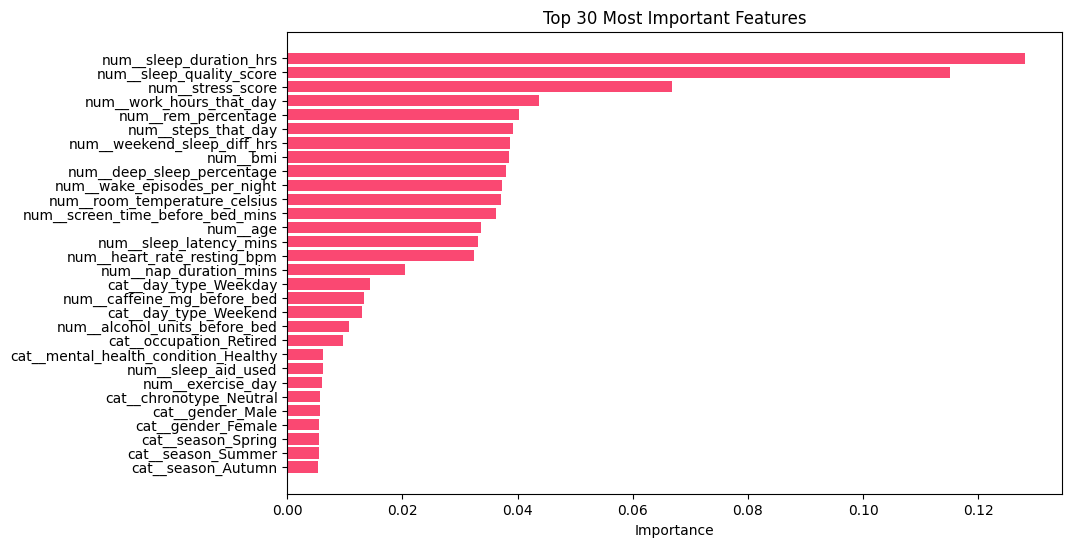

In [88]:
import matplotlib.pyplot as plt

top_features = importance_df.head(30)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"], color="#fa4872"
)

plt.xlabel("Importance")
plt.title("Top 30 Most Important Features")

plt.gca().invert_yaxis()

plt.show()

Feature importance is not causation.

If Random Forest says:

> Stress Score → 0.20

it does not mean: "Stress causes 20% of sleep quality."

It simply means:

> This feature was useful for making predictions.

That's an important distinction.

> Feature importance analysis revealed that Sleep Duration, Sleep Quality Score, and Stress Score were the three most influential predictors of whether an individual felt rested. This aligned closely with the exploratory data analysis, increasing confidence that the learned patterns were consistent with the observed relationships in the dataset.

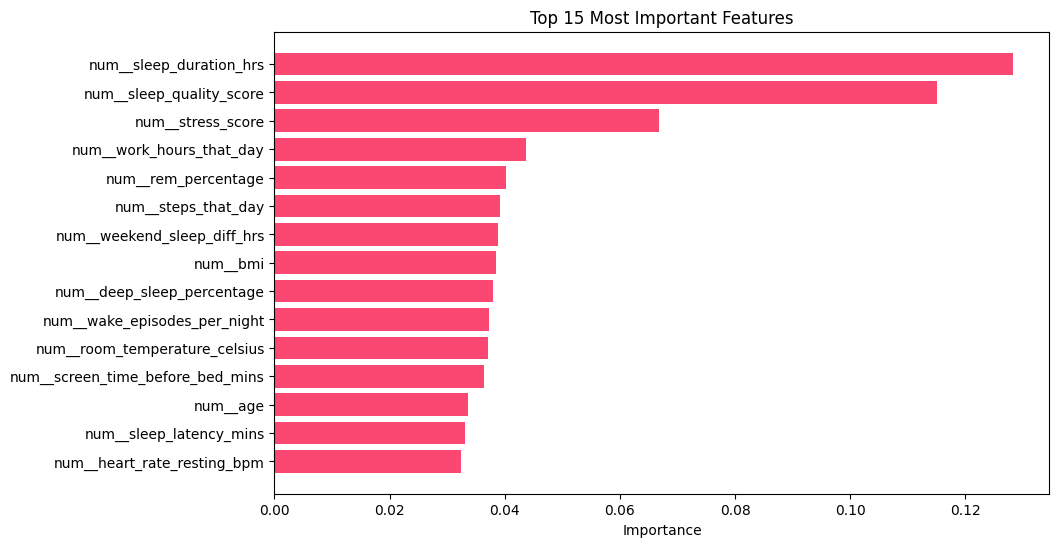

In [87]:
import matplotlib.pyplot as plt

top_features = importance_df.nlargest(15, "Importance")
plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"], color="#fa4872"
)

plt.xlabel("Importance")
plt.title("Top 15 Most Important Features")

plt.gca().invert_yaxis()

plt.show()

## Comparing with XGBoost

### Import

In [90]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

### Build Pipeline

In [91]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                random_state=42,
                n_estimators=200,
                learning_rate=0.1,
                max_depth=6,
                eval_metric="logloss"
            )
        )
    ]
)

**n_estimators=200**

Number of trees.

More trees generally improve performance, but training takes longer and too many can lead to overfitting.

**learning_rate=0.1**

Every tree only makes a small correction to the previous ensemble.

Instead of one huge jump:
```
Prediction
↓
Large Correction
```
it does
```
Prediction
↓
Small Correction
↓
Small Correction
↓
Small Correction
```

This gradual learning is one reason XGBoost often performs so well.

**max_depth=6**

Limits how deep each tree can grow.

> If trees are too deep: Overfit

> Too shallow: Underfit

A depth of around 6 is a common starting point.

**eval_metric="logloss"**

This tells XGBoost which metric to optimize internally for binary classification and avoids deprecation warnings.



## Train

In [92]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi',
                                                   'sleep_duration_hrs',
                                                   'sleep_quality_score',
                                                   'rem_percentage',
                                                   'deep_sleep_percentage',
                                                   'sleep_latency_mins',
                                                   'wake_episodes_per_night',
                                                   'caffeine_mg_before_bed',
                                                   'alcohol_units_before_bed',
                                                   'screen_time_before_bed_mins',
                                                   'exercise_day',
                                                   'steps_that_day',
                                                   'nap...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

### Predict

In [93]:
y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)

In [95]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(f"ROC-AUC: {roc_auc_score(y_test, y_prob[:,1]):.4f}")

Accuracy: 0.7378
              precision    recall  f1-score   support

           0       0.78      0.80      0.79     12198
           1       0.67      0.64      0.65      7802

    accuracy                           0.74     20000
   macro avg       0.72      0.72      0.72     20000
weighted avg       0.74      0.74      0.74     20000

[[9781 2417]
 [2827 4975]]
ROC-AUC: 0.8226


### Feature Importance

In [96]:
xgb_model = pipeline.named_steps["model"]

feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(15))

                                 Feature  Importance
3               num__sleep_quality_score    0.253294
2                num__sleep_duration_hrs    0.106365
7           num__wake_episodes_per_night    0.041309
14                     num__stress_score    0.027124
62                 cat__day_type_Weekday    0.025434
31               cat__occupation_Retired    0.014842
57  cat__mental_health_condition_Healthy    0.014264
48                   cat__country_Sweden    0.011941
42                    cat__country_Italy    0.011885
32                 cat__occupation_Sales    0.011814
4                    num__rem_percentage    0.011395
26            cat__occupation_Freelancer    0.011268
37                   cat__country_Brazil    0.011093
25                cat__occupation_Driver    0.010700
38                   cat__country_Canada    0.010683


## Final Model Comparision

| Model               |   Accuracy | Precision |   Recall |       F1 |    ROC-AUC |
| ------------------- | ---------: | --------: | -------: | -------: | ---------: |
| Logistic Regression | **0.7363** |  **0.68** | **0.60** | **0.64** | **0.8125** |
| Random Forest       | **0.7372** |  **0.68** | **0.62** | **0.65** | **0.8200** |
| XGBoost             | **0.7378** |  **0.67** | **0.64** | **0.65** | **0.8226** |


| Model               |   Accuracy | Precision |  Recall |      F1 |    ROC-AUC |
| ------------------- | ---------: | --------: | ------: | ------: | ---------: |
| Logistic Regression | **73.63%** |   **68%** | **60%** | **64%** | **81.25%** |
| Random Forest       | **73.72%** |   **68%** | **62%** | **65%** | **82.00%** |
| XGBoost             | **73.78%** |   **67%** | **64%** | **65%** | **82.26%** |


| Model               | Observation                        |
| ------------------- | ---------------------------------- |
| Logistic Regression | Strong baseline                    |
| Random Forest       | Small improvement                  |
| XGBoost             | Slightly better than Random Forest |


## Conclusion

> Three different machine learning models were trained and evaluated on the sleep health dataset. Logistic Regression provided a strong baseline performance. Random Forest and XGBoost achieved modest improvements in Recall, F1-score, and ROC-AUC, while overall Accuracy remained similar across all models. Based on the evaluation metrics, XGBoost achieved the best overall performance and was selected as the final model for this project.